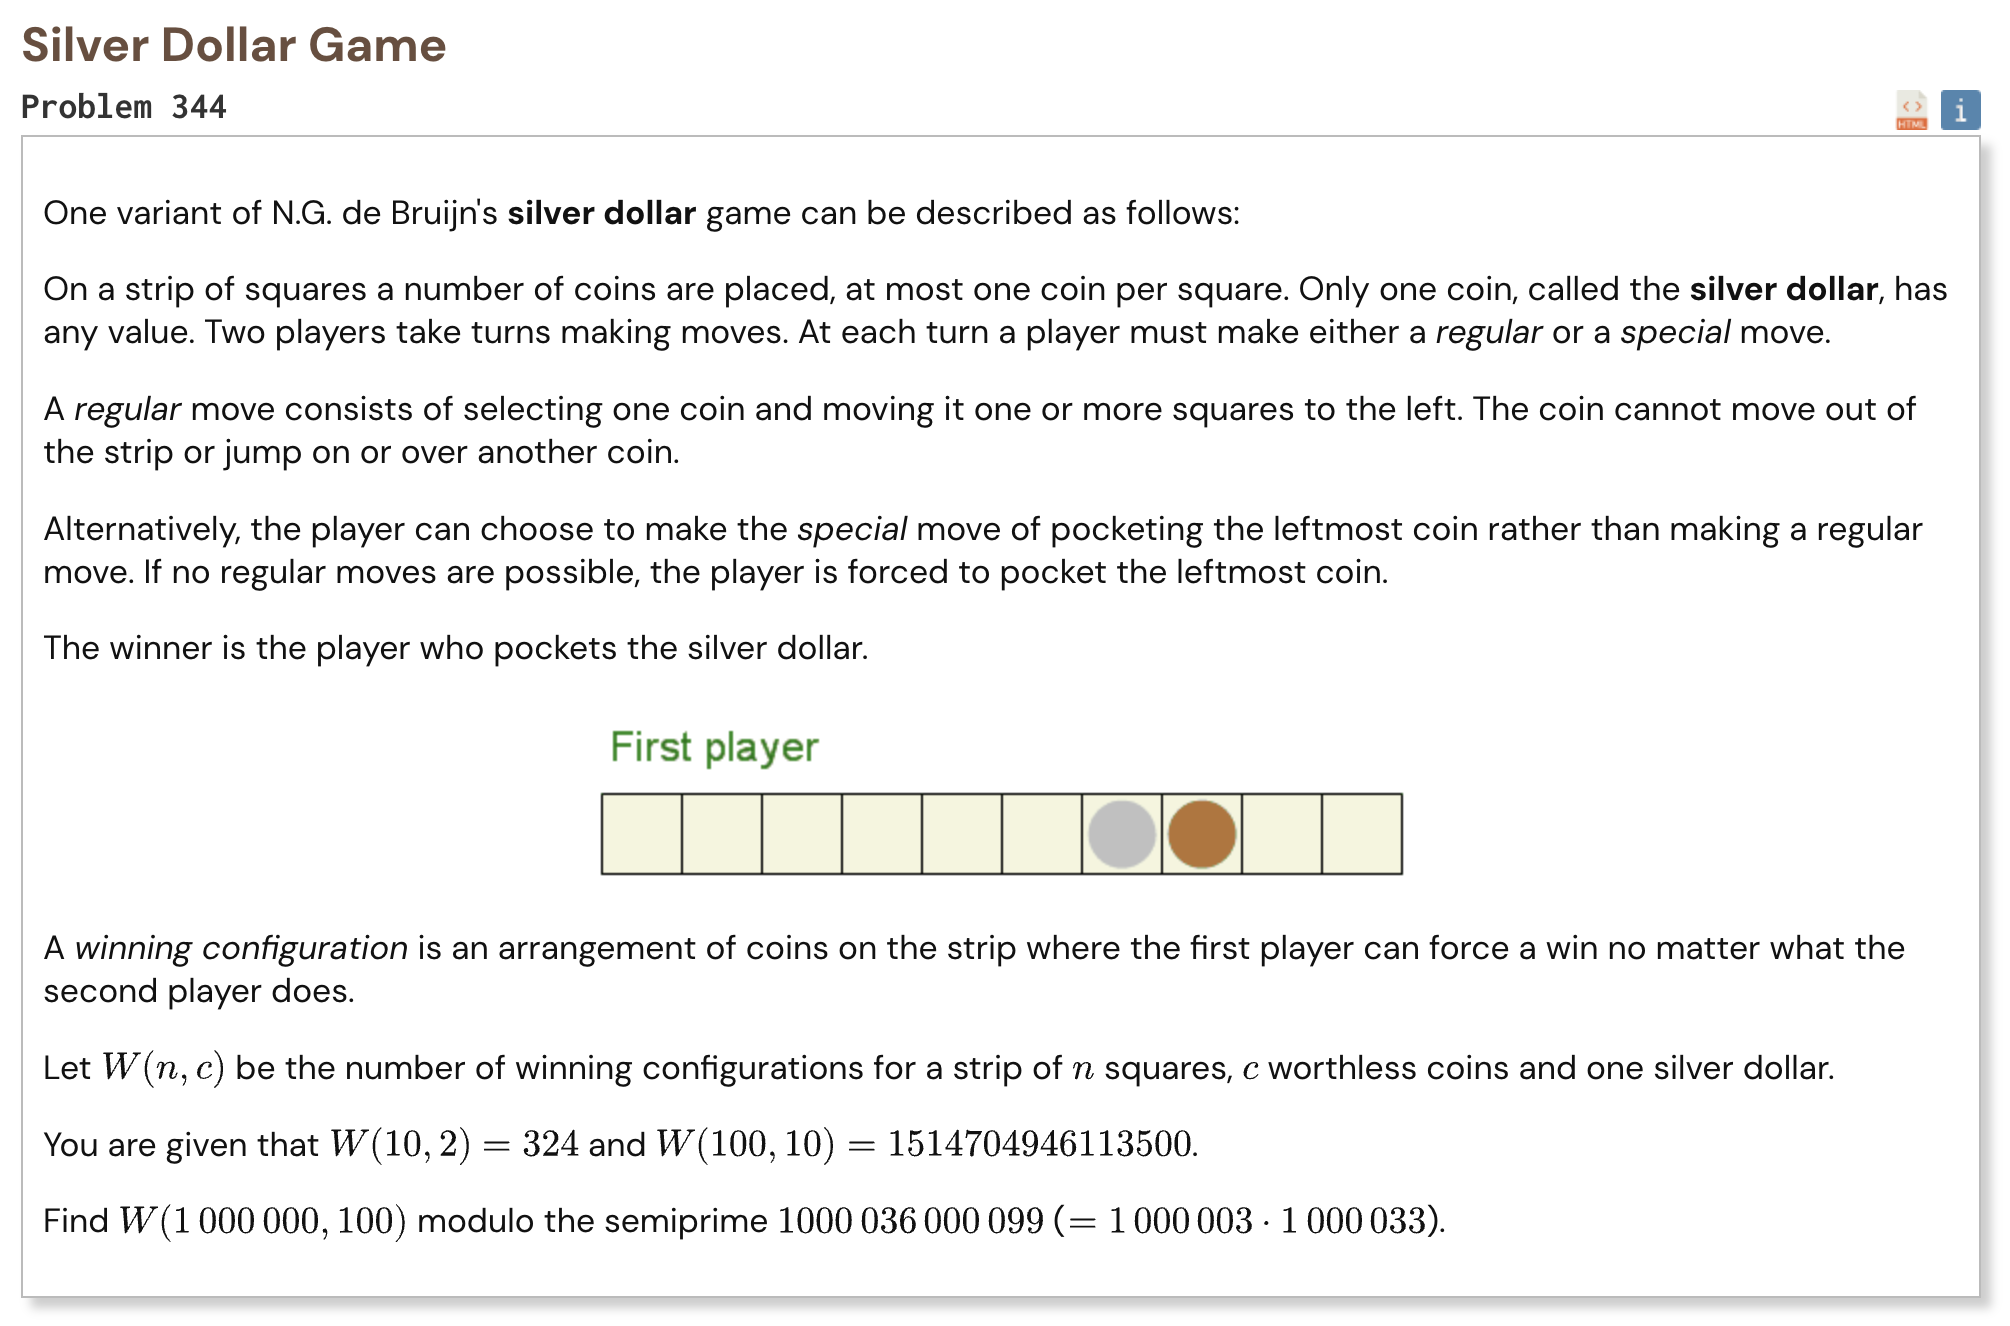

## Initial approach

* convert coin positions into gaps between coins
* regular moves become the usual silver-dollar gap game
* losing states are counted by an xor-zero condition on alternating gaps
* the special pocket move splits losing states into two cases
* count fixed-sum gap vectors bit by bit using carry DP
* subtract losing configurations from all possible configurations
* use CRT because the final modulus is a product of two primes

In [1]:
from math import comb

MOD = 1_000_036_000_099
P1 = 1_000_003
P2 = 1_000_033

def build_ways(active, passive, mod=None):
    ways = [0] * (active + passive + 1)

    for active_ones in range(0, active + 1, 2):
        active_choices = comb(active, active_ones)

        for passive_ones in range(passive + 1):
            ones = active_ones + passive_ones
            value = active_choices * comb(passive, passive_ones)

            if mod is None:
                ways[ones] += value
            else:
                ways[ones] = (ways[ones] + value) % mod

    return ways

def count_with_ways(total_sum, ways, mod=None):
    terms = [(ones, count) for ones, count in enumerate(ways) if count]
    dp = [1]

    for bit_index in range(total_sum.bit_length()):
        target_bit = (total_sum >> bit_index) & 1
        next_dp = [0] * (len(dp) + len(ways) // 2 + 2)

        for carry, value in enumerate(dp):
            if value == 0:
                continue

            for ones, count in terms:
                column_total = carry + ones

                if (column_total & 1) != target_bit:
                    continue

                next_carry = (column_total - target_bit) // 2

                if mod is None:
                    next_dp[next_carry] += value * count
                else:
                    next_dp[next_carry] = (next_dp[next_carry] + value * count) % mod

        dp = next_dp

    return dp[0]

def binomial_mod_prime_small_k(n, k, prime):
    if k < 0 or k > n:
        return 0

    k = min(k, n - k)
    numerator = 1
    denominator = 1
    offset = n - k

    for i in range(1, k + 1):
        numerator = numerator * (offset + i) % prime
        denominator = denominator * i % prime

    return numerator * pow(denominator, prime - 2, prime) % prime

def losing_count(n, c, mod=None):
    coin_count = c + 1
    empty_squares = n - coin_count
    active = (coin_count + 1) // 2
    passive = coin_count - active + 1

    active_ways = build_ways(active, passive, mod)
    reduced_active_ways = build_ways(active - 1, passive, mod)

    second_coin = count_with_ways(empty_squares, active_ways, mod)
    other_coins = count_with_ways(empty_squares + 1, active_ways, mod)
    other_coins -= count_with_ways(empty_squares + 1, reduced_active_ways, mod)

    if mod is None:
        return second_coin + (coin_count - 2) * other_coins

    return (second_coin + (coin_count - 2) * other_coins) % mod

def W_exact_even_c(n, c):
    coin_count = c + 1
    return coin_count * comb(n, coin_count) - losing_count(n, c)

def W_mod_even_c(n, c):
    coin_count = c + 1

    def solve_prime(prime):
        total = coin_count * binomial_mod_prime_small_k(n, coin_count, prime)
        return (total - losing_count(n, c, prime)) % prime

    residue_1 = solve_prime(P1)
    residue_2 = solve_prime(P2)

    t = ((residue_2 - residue_1) % P2) * pow(P1, -1, P2) % P2
    return (residue_1 + P1 * t) % MOD

assert W_exact_even_c(10, 2) == 324
assert W_exact_even_c(100, 10) == 1_514_704_946_113_500

In [2]:
%%time
result = W_mod_even_c(1_000_000, 100)
print("Result:", result)

Result: 65579304332
CPU times: user 109 ms, sys: 2.25 ms, total: 111 ms
Wall time: 110 ms
